In [ ]:
!pip install fitz PyMuPDF sentence_transformers pulp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.7/110.7 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.9/425.9 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.2/587.2 kB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 5.5 MB/s eta 0:00:00


In [ ]:
!pip uninstall -y fitz

Found existing installation: fitz 0.0.1.dev2
Uninstalling fitz-0.0.1.dev2:
  Successfully uninstalled fitz-0.0.1.dev2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pymupdf

In [ ]:
!pip install pdfplumber

import pdfplumber
import os
from sentence_transformers import SentenceTransformer
import numpy as np
import pulp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 130.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 121.5 MB/s eta 0:00:00


# Paper Allocation System with Optimization

This notebook implements a paper-reviewer matching system using:
- **Sentence embeddings** for computing paper-reviewer similarity
- **Linear programming** for optimal assignment subject to constraints

In [ ]:
# Extract text from PDF
def extract_text(pdf_path, max_pages=5):
    """
    Extract text from first few pages of a PDF.

    Args:
        pdf_path: Path to PDF file
        max_pages: Maximum number of pages to extract

    Returns:
        Extracted text string
    """
    text = ""
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for i, page in enumerate(pdf.pages[:max_pages]):
                text += page.extract_text() or ""
    except Exception as e:
        print(f"Error extracting text from {pdf_path}: {e}")
    return text

# Load embedding model
print("Loading embedding model...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded successfully!")

Loading embedding model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully!


In [ ]:
papers_dir = "/content/drive/MyDrive/papers"

# Get PDF files
paper_files = sorted([f for f in os.listdir(papers_dir) if f.endswith('.pdf')])[:4] # ONly 4 papers for testing

print(f"Found {len(paper_files)} papers")

# Extract text
print("\nExtracting text from papers...")
paper_texts = [extract_text(os.path.join(papers_dir, f)) for f in paper_files]

print("Extracting text from reviewer profiles...")
reviewer_texts  = [
    "Expert in machine learning, deep learning, and natural language processing.",
    "Expert in deep learning and NLP with strong experience in Transformer models, attention mechanisms, sequence-to-sequence learning, and neural machine translation",
    "Background in NLP , machine Learniing.",
    "Works on reinforcement learning, robotics, and control systems."
]


print("\nText extraction complete!")

Found 4 papers

Extracting text from papers...
Extracting text from reviewer profiles...

Text extraction complete!


In [ ]:
print("Generating embeddings for papers...")
paper_embeddings = model.encode(paper_texts, show_progress_bar=True)

print("\nGenerating embeddings for reviewers...")
reviewer_embeddings = model.encode(reviewer_texts, show_progress_bar=True)

print("\nEmbeddings generated!")

Generating embeddings for papers...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Generating embeddings for reviewers...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Embeddings generated!


In [ ]:
# Compute similarity matrix
from sklearn.metrics.pairwise import cosine_similarity

# sim[p][r] = similarity between paper p and reviewer r
sim = cosine_similarity(paper_embeddings, reviewer_embeddings)

print(f"Similarity matrix shape: {sim.shape}")
print(f"\nSample similarities (Paper 0):")
for r in range(len(reviewer_texts)):
    print(f"  Reviewer {r}: {sim[0][r]:.3f}")

Similarity matrix shape: (4, 4)

Sample similarities (Paper 0):
  Reviewer 0: 0.234
  Reviewer 1: 0.432
  Reviewer 2: 0.227
  Reviewer 3: 0.106


## Optimization Problem Setup

### Variables:
- `x[p][r]` = 1 if paper `p` is assigned to reviewer `r`, else 0

### Objective:
- Maximize total similarity score

### Constraints:
1. Each paper gets exactly `K` reviewers
2. Each reviewer reviews at most `capacity[r]` papers
3. Binary assignment (0 or 1)

In [ ]:
# Problem parameters
P = len(paper_files)      # Number of papers
R = len(reviewer_texts)   # Number of reviewers
K = 2                    # Reviewers per paper

# Reviewer capacities (max papers each reviewer can handle)
# Adjust these based on your reviewers' availability
capacity = [2, 3, 2,  3]

print(f"Papers: {P}")
print(f"Reviewers: {R}")
print(f"Reviewers per paper: {K}")
print(f"Reviewer capacities: {capacity}")

# Feasibility check
total_capacity = sum(capacity)
total_needed = P * K

print(f"\nFeasibility Check:")
print(f"  Total reviewer capacity: {total_capacity}")
print(f"  Total assignments needed: {total_needed}")

if total_capacity < total_needed:
    print(f"  ⚠️  WARNING: Problem is INFEASIBLE!")
    print(f"  Need {total_needed - total_capacity} more reviewer capacity")
    print(f"  Consider: reducing K, increasing capacities, or adding reviewers")
else:
    print(f"  ✓ Problem is potentially feasible (capacity sufficient)")

Papers: 4
Reviewers: 4
Reviewers per paper: 2
Reviewer capacities: [2, 3, 2, 3]

Feasibility Check:
  Total reviewer capacity: 10
  Total assignments needed: 8
  ✓ Problem is potentially feasible (capacity sufficient)


In [ ]:
# Create optimization problem
prob = pulp.LpProblem("PaperReviewerAssignment", pulp.LpMaximize)

# Decision variables: x[p][r] = 1 if paper p assigned to reviewer r
x = pulp.LpVariable.dicts(
    "assignment",
    ((p, r) for p in range(P) for r in range(R)),
    cat="Binary"
)

print(f"Created {len(x)} decision variables")

Created 16 decision variables


In [ ]:
# Objective: Maximize total similarity score
prob += pulp.lpSum(
    sim[p][r] * x[(p, r)]
    for p in range(P)
    for r in range(R)
), "TotalSimilarity"

print("Objective function set: Maximize total similarity")

Objective function set: Maximize total similarity


In [ ]:
# Constraint 1: Each paper must be assigned to exactly K reviewers
for p in range(P):
    prob += (
        pulp.lpSum(x[(p, r)] for r in range(R)) == K,
        f"Paper_{p}_gets_{K}_reviewers"
    )

print(f"Added {P} constraints: Each paper gets exactly {K} reviewers")

Added 4 constraints: Each paper gets exactly 2 reviewers


In [ ]:
# Constraint 2: Each reviewer can handle at most capacity[r] papers
for r in range(R):
    prob += (
        pulp.lpSum(x[(p, r)] for p in range(P)) <= capacity[r],
        f"Reviewer_{r}_capacity_{capacity[r]}"
    )

print(f"Added {R} constraints: Reviewer capacity limits")

Added 4 constraints: Reviewer capacity limits


In [ ]:
# Solve the optimization problem
print("Solving optimization problem...")
print("This may take a few moments...\n")

status = prob.solve(pulp.PULP_CBC_CMD(msg=1))

print(f"\n{'='*60}")
print(f"OPTIMIZATION RESULT")
print(f"{'='*60}")
print(f"Status: {pulp.LpStatus[status]}")

if status == pulp.LpStatusOptimal:
    print(f"Objective Value (Total Similarity): {pulp.value(prob.objective):.4f}")
    print(f"Average Similarity per Assignment: {pulp.value(prob.objective)/(P*K):.4f}")
elif status == pulp.LpStatusInfeasible:
    print("❌ INFEASIBLE - Cannot satisfy all constraints")
    print("\nPossible solutions:")
    print("  1. Reduce K (reviewers per paper)")
    print("  2. Increase reviewer capacities")
    print("  3. Add more reviewers")
else:
    print(f"⚠️  Unexpected status: {pulp.LpStatus[status]}")

Solving optimization problem...
This may take a few moments...


OPTIMIZATION RESULT
Status: Optimal
Objective Value (Total Similarity): 3.0269
Average Similarity per Assignment: 0.3784


In [ ]:
# Extract and display results (only if optimal solution found)
if pulp.LpStatus[status] == 'Optimal':
    # Build assignment mappings
    paper_to_reviewers = {p: [] for p in range(P)}
    reviewer_to_papers = {r: [] for r in range(R)}

    for p in range(P):
        for r in range(R):
            if pulp.value(x[(p, r)]) == 1:
                paper_to_reviewers[p].append(r)
                reviewer_to_papers[r].append(p)

    print(f"\n{'='*60}")
    print("PAPER → REVIEWERS ASSIGNMENT")
    print(f"{'='*60}\n")

    for p in range(P):
        print(f"📄 Paper {p}: {paper_files[p]}")
        if paper_to_reviewers[p]:
            for r in paper_to_reviewers[p]:
                score = sim[p][r]
                print(f"   ✓ Reviewer {r} (similarity: {score:.3f})")
        else:
            print("   ❌ No reviewers assigned")
        print()

    print(f"\n{'='*60}")
    print("REVIEWER → PAPERS ASSIGNMENT")
    print(f"{'='*60}\n")

    for r in range(R):
        print(f"👤 Reviewer {r}: {reviewer_texts[r]}")
        print(f"   Capacity: {capacity[r]} | Assigned: {len(reviewer_to_papers[r])}")

        if reviewer_to_papers[r]:
            for p in reviewer_to_papers[r]:
                score = sim[p][r]
                print(f"   ✓ Paper {p}: {paper_files[p]} (similarity: {score:.3f})")
        else:
            print("   No papers assigned")
        print()

    # Summary statistics
    print(f"\n{'='*60}")
    print("ASSIGNMENT SUMMARY")
    print(f"{'='*60}\n")

    all_scores = [sim[p][r] for p in range(P) for r in paper_to_reviewers[p]]

    print(f"Total assignments: {len(all_scores)}")
    print(f"Average similarity: {np.mean(all_scores):.4f}")
    print(f"Min similarity: {np.min(all_scores):.4f}")
    print(f"Max similarity: {np.max(all_scores):.4f}")
    print(f"Std deviation: {np.std(all_scores):.4f}")

    # Reviewer workload
    print(f"\nReviewer Workload:")
    for r in range(R):
        workload = len(reviewer_to_papers[r])
        utilization = (workload / capacity[r] * 100) if capacity[r] > 0 else 0
        print(f"  Reviewer {r}: {workload}/{capacity[r]} papers ({utilization:.1f}% capacity)")

else:
    print("\n⚠️  Cannot display results - optimization did not find a solution")


PAPER → REVIEWERS ASSIGNMENT

📄 Paper 0: Attention Is all you need.pdf
   ✓ Reviewer 1 (similarity: 0.432)
   ✓ Reviewer 3 (similarity: 0.106)

📄 Paper 1: Deep Learning in Neural networks.pdf
   ✓ Reviewer 0 (similarity: 0.449)
   ✓ Reviewer 1 (similarity: 0.468)

📄 Paper 2: Distilling the Knowledge in a Neural Network.pdf
   ✓ Reviewer 1 (similarity: 0.427)
   ✓ Reviewer 2 (similarity: 0.369)

📄 Paper 3: Exploring the Landscape of Natural Language Processing Research.pdf
   ✓ Reviewer 0 (similarity: 0.308)
   ✓ Reviewer 2 (similarity: 0.468)


REVIEWER → PAPERS ASSIGNMENT

👤 Reviewer 0: Expert in machine learning, deep learning, and natural language processing.
   Capacity: 2 | Assigned: 2
   ✓ Paper 1: Deep Learning in Neural networks.pdf (similarity: 0.449)
   ✓ Paper 3: Exploring the Landscape of Natural Language Processing Research.pdf (similarity: 0.308)

👤 Reviewer 1: Expert in deep learning and NLP with strong experience in Transformer models, attention mechanisms, sequence-to

## Additional Analysis

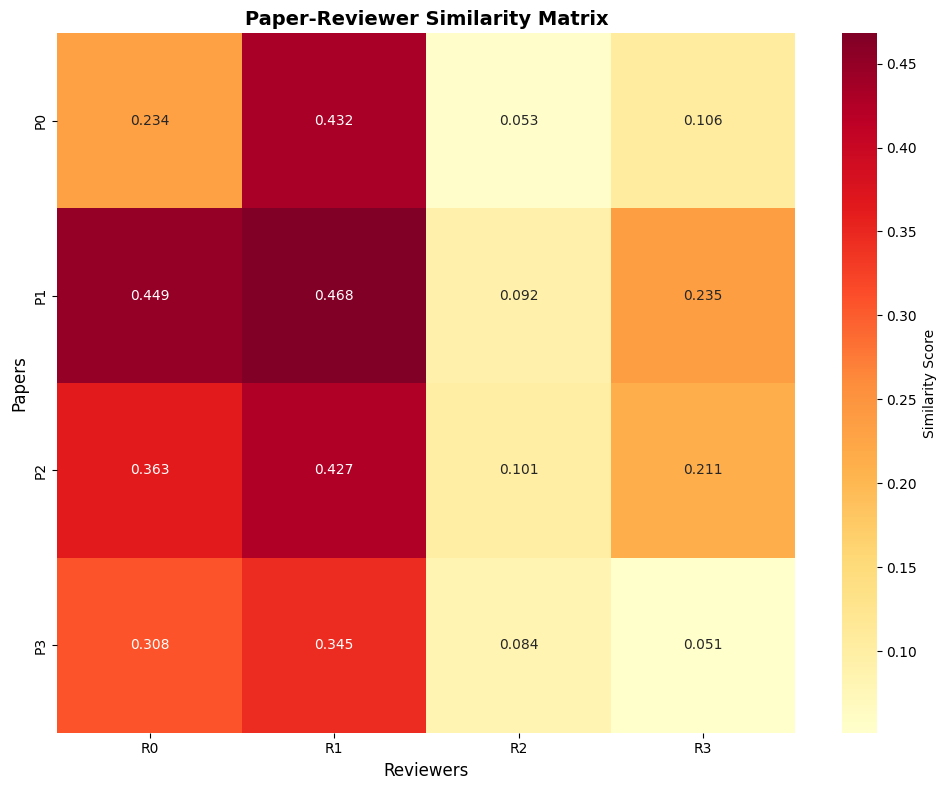

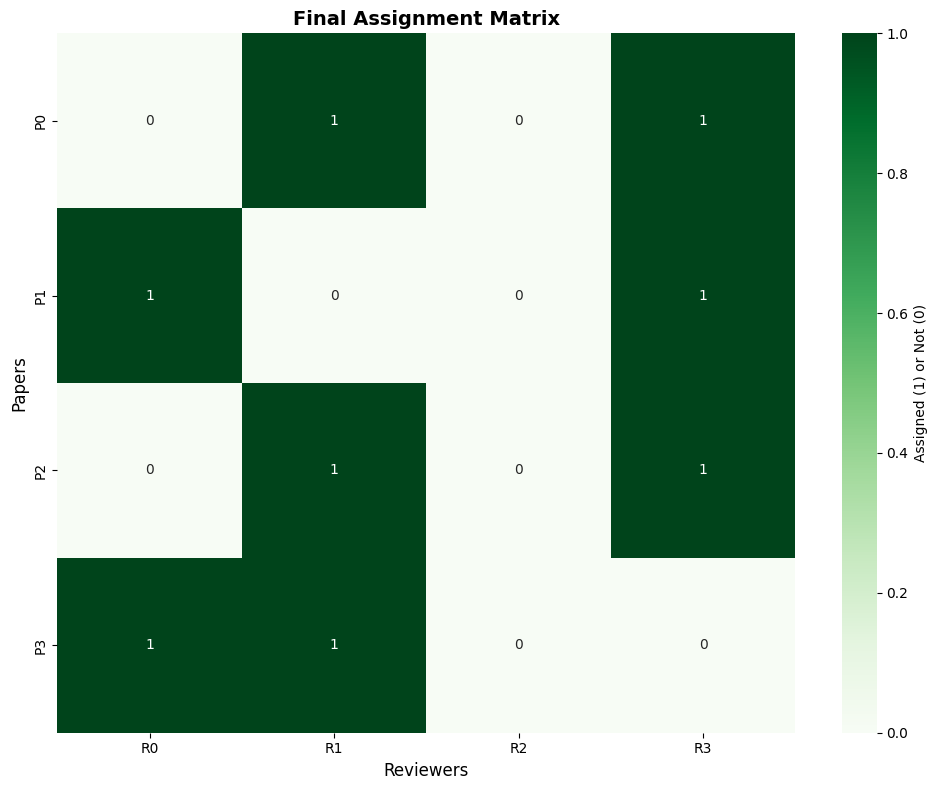

In [ ]:
# Visualize similarity matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(sim, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=[f"R{r}" for r in range(R)],
            yticklabels=[f"P{p}" for p in range(P)],
            cbar_kws={'label': 'Similarity Score'})
plt.title('Paper-Reviewer Similarity Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Reviewers', fontsize=12)
plt.ylabel('Papers', fontsize=12)
plt.tight_layout()
plt.show()

# If solution exists, highlight assignments
if pulp.LpStatus[status] == 'Optimal':
    assignment_matrix = np.zeros((P, R))
    for p in range(P):
        for r in range(R):
            if pulp.value(x[(p, r)]) == 1:
                assignment_matrix[p][r] = 1

    plt.figure(figsize=(10, 8))
    sns.heatmap(assignment_matrix, annot=True, fmt='.0f', cmap='Greens',
                xticklabels=[f"R{r}" for r in range(R)],
                yticklabels=[f"P{p}" for p in range(P)],
                cbar_kws={'label': 'Assigned (1) or Not (0)'})
    plt.title('Final Assignment Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Reviewers', fontsize=12)
    plt.ylabel('Papers', fontsize=12)
    plt.tight_layout()
    plt.show()

## Export Results

In [ ]:
# Export assignments to CSV
if pulp.LpStatus[status] == 'Optimal':
    import pandas as pd

    # Create assignment list
    assignments = []
    for p in range(P):
        for r in paper_to_reviewers[p]:
            assignments.append({
                'Paper_ID': p,
                'Paper_Name': paper_files[p],
                'Reviewer_ID': r,
                'Reviewer_Name': reviewer_files[r],
                'Similarity_Score': sim[p][r]
            })

    df = pd.DataFrame(assignments)
    df.to_csv('paper_reviewer_assignments.csv', index=False)
    print("✓ Assignments exported to 'paper_reviewer_assignments.csv'")
    print(f"\nFirst few rows:")
    display(df.head(10))
else:
    print("⚠️  No assignments to export")

## Adjusting Parameters

If the problem is infeasible, try:

1. **Reduce `K`** (reviewers per paper):
   ```python
   K = 2  # Instead of 3
   ```

2. **Increase reviewer capacities**:
   ```python
   capacity = [3, 4, 2, 4]  # Instead of [2, 3, 1, 3]
   ```

3. **Add more reviewers** to the `/content/reviewers` directory

4. **Use variable K** (different papers can have different numbers of reviewers):
   ```python
   # Instead of: prob += sum(x[p][r] for r in range(R)) == K
   # Use: prob += sum(x[p][r] for r in range(R)) >= K_min
   #      prob += sum(x[p][r] for r in range(R)) <= K_max
   ```